In [3]:
#Local dataset

In [2]:
import tensorflow as tf
import os 

dr = r"c:\Users\visha\Downloads\Vehicles"

#to check corrupt files, time lagega lekin maja aayega
for root,dirs,files in os.walk(dr):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            img = tf.io.decode_image(tf.io.read_file(file_path))
        except:
            print(f"{file_path} nikl yaha se")
            os.remove(file_path)


c:\Users\visha\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


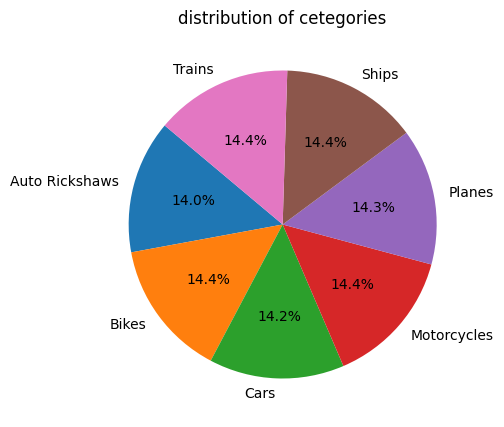

[]

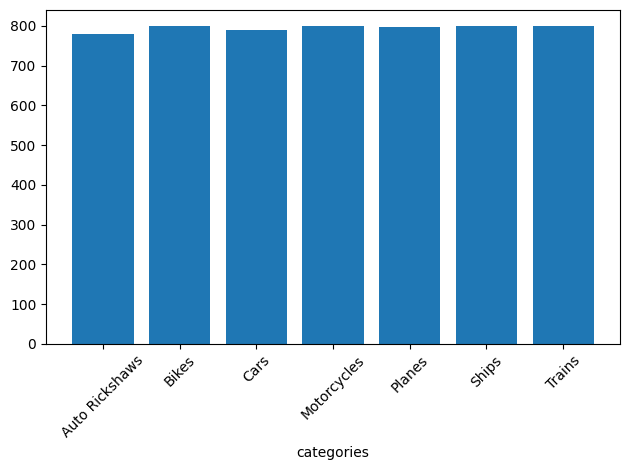

In [4]:
from collections import Counter
import matplotlib.pyplot as plt

labels = []
plt.figure(figsize=(15,5))

for label in os.listdir(dr):
    for image in os.listdir(os.path.join(dr,label)):
        labels.append(label)

value_counts = Counter(labels)

labels_key = list(value_counts.keys())
values = list(value_counts.values())


plt.title('distribution of cetegories')
plt.pie(values, labels=labels_key, autopct='%1.1f%%', startangle=140)
plt.show()

plt.bar(labels_key, values)
plt.xticks(labels_key, rotation=45)  
plt.xlabel('categories')


plt.tight_layout()
plt.plot()

In [5]:

train_ds = tf.keras.utils.image_dataset_from_directory(dr,validation_split=0.2,subset="training",seed=42,image_size=(254,254),batch_size=32,label_mode="categorical")

val_ds = tf.keras.utils.image_dataset_from_directory(dr,validation_split=0.2,subset="validation",seed=42,image_size=(254,254),batch_size=32,label_mode="categorical",)

classes_name = train_ds.class_names
train_ds = train_ds.map(lambda x,y: (x/255.0, y))
val_ds   = val_ds.map(lambda x,y: (x/255.0, y))

print(classes_name)

Found 5568 files belonging to 7 classes.
Using 4455 files for training.
Found 5568 files belonging to 7 classes.
Using 1113 files for validation.
['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']


In [6]:
print(type(train_ds))
print(len(train_ds)) # 140x32
data = [i for i in train_ds]
print(len(data),type(data))
#data has 140 batches of 32 images 

<class 'tensorflow.python.data.ops.map_op._MapDataset'>
140
140 <class 'list'>


In [7]:
print("total batches in data : ",len(data))
print("each batch has tuple for images and labels: ",len(data[0]))
print("each batch has tuple for images and labels: ",data[0][0].shape)
print("each batch has tuple for images and labels: ",data[0][0][0].shape)

total batches in data :  140
each batch has tuple for images and labels:  2
each batch has tuple for images and labels:  (32, 254, 254, 3)
each batch has tuple for images and labels:  (254, 254, 3)


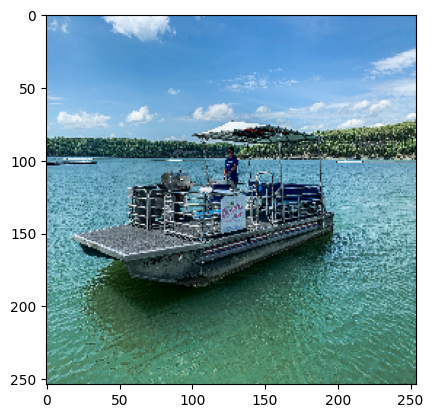

In [8]:
img = data[0][0][6]
import matplotlib.pyplot as plt
plt.imshow(img)

In [ ]:
#EDA

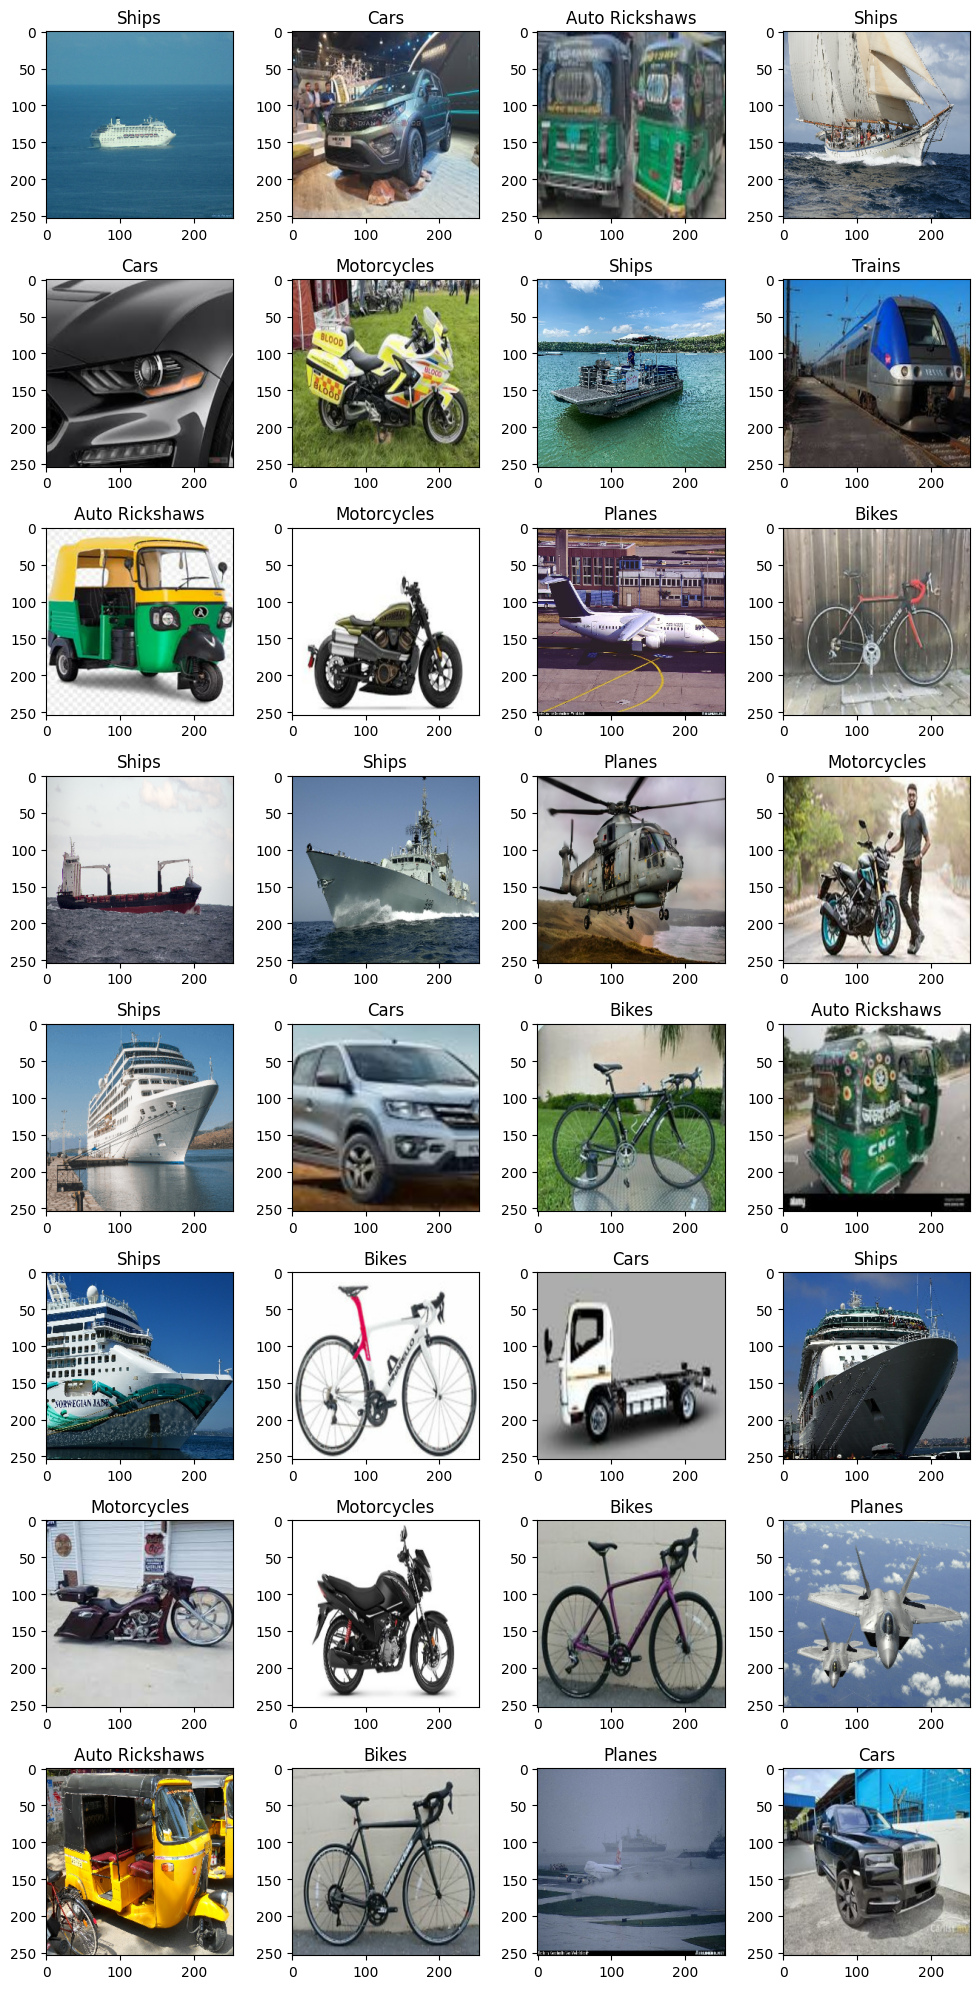

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,20))

for i in range(32):
    plt.subplot(8,4,i+1)
    img = data[0][0][i]
    label = data[0][1][i]
    plt.title(f"{classes_name[np.argmax(label)]}")
    plt.imshow(img,cmap="viridis")
plt.tight_layout()
plt.show()

In [11]:

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(128,3,activation='relu',input_shape=(254,254,3),padding='same'),
    tf.keras.layers.GlobalMaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(len(classes_name),activation='softmax')
])
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 254, 254, 128)     3584      
                                                                 
 global_max_pooling2d_1 (Gl  (None, 128)               0         
 obalMaxPooling2D)                                               
                                                                 
 flatten_1 (Flatten)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 256)               33024     
                                                                 
 dense_3 (Dense)             (None, 7)                 1799      
                                                                 
Total params: 38407 (150.03 KB)
Trainable params: 38407 (150.03 KB)
Non-trainable params: 0 (0.00 Byte)
________________

In [12]:

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

model.compile(optimizer=optimizer,loss='categorical_crossentropy',metrics=['accuracy'])

model.fit(train_ds, validation_data=val_ds, epochs=5)


Epoch 1/5




140/140 [==============================] - 214s 1s/step - loss: 1.9329 - accuracy: 0.2141 - val_loss: 1.9220 - val_accuracy: 0.2525
Epoch 2/5
140/140 [==============================] - 206s 1s/step - loss: 1.9103 - accuracy: 0.3030 - val_loss: 1.9031 - val_accuracy: 0.3585
Epoch 3/5
140/140 [==============================] - 204s 1s/step - loss: 1.8902 - accuracy: 0.3120 - val_loss: 1.8828 - val_accuracy: 0.3387
Epoch 4/5
140/140 [==============================] - 213s 2s/step - loss: 1.8644 - accuracy: 0.3295 - val_loss: 1.8568 - val_accuracy: 0.3477
Epoch 5/5
140/140 [==============================] - 211s 1s/step - loss: 1.8326 - accuracy: 0.3490 - val_loss: 1.8274 - val_accuracy: 0.3118


In [ ]:
model.save(r"c:\Users\visha\Downloads\Vehicles\vehicle_model.keras")

NameError: name 'tf' is not defined